# Analyse causale — Équipe au choix

**Seule cellule à modifier : la cellule de configuration ci-dessous.**
Renseigne le nom de l'équipe et les années souhaitées, puis lance tout.

## ⚙️ Configuration — À modifier

In [14]:
# ══════════════════════════════════════════════════════════
# MODIFIER ICI UNIQUEMENT
# ══════════════════════════════════════════════════════════

EQUIPE  = 'Groupama - FDJ'       # Nom exact de l'equipe (tel qu'il apparait dans les CSV)
ANNEES  = [2025]                  # Liste d'annees : [2025] ou [2024, 2025] ou list(range(2021, 2026))

# ══════════════════════════════════════════════════════════
# NE PAS MODIFIER EN DESSOUS
# ══════════════════════════════════════════════════════════

RIDER_DIR = '/Users/arthurdeletang/Desktop/Stage M1/Code/rider_data'
RACE_PATH = '/Users/arthurdeletang/Desktop/Stage M1/Code/race_data/race_features.csv'

print(f'Equipe  : {EQUIPE}')
print(f'Annees  : {ANNEES}')

Equipe  : Groupama - FDJ
Annees  : [2025]


## 0. Imports

In [15]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from econml.dml import CausalForestDML
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_rows', 60)

## 1. Détection automatique des coureurs

In [16]:
# Detecter automatiquement tous les coureurs de l'equipe sur les annees choisies
def find_team_riders(equipe, annees, rider_dir):
    """
    Parcourt tous les CSV coureurs et retourne ceux
    qui ont au moins une ligne dans l'equipe sur les annees choisies.
    """
    riders_found = []
    all_files = [f for f in os.listdir(rider_dir) if f.endswith('.csv')]

    for f in all_files:
        try:
            df = pd.read_csv(os.path.join(rider_dir, f), usecols=['year', 'equipe'])
            mask = (df['year'].isin(annees)) & (df['equipe'] == equipe)
            if mask.any():
                riders_found.append(f)
        except Exception:
            continue

    return sorted(riders_found)

print('Recherche des coureurs... (peut prendre 30s)')
RIDERS = find_team_riders(EQUIPE, ANNEES, RIDER_DIR)
print(f'Coureurs trouves : {len(RIDERS)}')
for r in RIDERS:
    print(f'  {r}')

Recherche des coureurs... (peut prendre 30s)
Coureurs trouves : 38
  agnoletto_blake.csv
  askey_lewis.csv
  barthe_cyril.csv
  bock_max.csv
  boulet_eliott.csv
  bower_lewis.csv
  braz_afonso_clément.csv
  bystrøm_sven_erik.csv
  cavagna_rémi.csv
  cushway_maximilian.csv
  daumas_rémi.csv
  davy_clément.csv
  decomble_maxime.csv
  donnenwirth_tom.csv
  fontaine_titouan.csv
  gaudu_david.csv
  geniets_kevin.csv
  germani_lorenzo.csv
  grégoire_baptiste.csv
  grégoire_romain.csv
  gruel_thibaud.csv
  jacobs_johan.csv
  kayser_aurélien.csv
  küng_stefan.csv
  le_gac_olivier.csv
  le_huitouze_eddy.csv
  loulergue_victor.csv
  madouas_valentin.csv
  martin_guillaume.csv
  molard_rudy.csv
  pacher_quentin.csv
  paleni_enzo.csv
  penhoët_paul.csv
  roberts_reef.csv
  rochas_rémy.csv
  rolland_brieuc.csv
  russo_clément.csv
  walls_matthew.csv


## 2. Chargement et jointure

In [17]:
def load_rider(filename, race_path, annees, equipe):
    df_rider = pd.read_csv(os.path.join(RIDER_DIR, filename))
    df_race  = pd.read_csv(race_path)

    df_rider = df_rider[df_rider['year'].isin(annees) & (df_rider['equipe'] == equipe)]
    if len(df_rider) == 0:
        return None

    df_rider['stage_num'] = pd.to_numeric(df_rider['etape'],    errors='coerce')
    df_rider['year']      = pd.to_numeric(df_rider['year'],     errors='coerce').astype('Int64')
    df_race['year']       = pd.to_numeric(df_race['year'],      errors='coerce').astype('Int64')
    df_race['stage_num']  = pd.to_numeric(df_race['stage_num'], errors='coerce')
    df_rider['rider']     = filename.replace('.csv', '')

    df_merged = df_rider.merge(
        df_race.drop(columns=['stage', 'classification', 'date'], errors='ignore'),
        on=['course', 'year', 'stage_num'],
        how='left'
    )
    return df_merged

# Charger tous les coureurs
dfs = []
for f in RIDERS:
    df = load_rider(f, RACE_PATH, ANNEES, EQUIPE)
    if df is not None and len(df) > 0:
        dfs.append(df)

df_team = pd.concat(dfs, ignore_index=True)

cols_gpx_check = ['distance_gpx_km', 'denivele_pos', 'altitude_max']
no_match = df_team[df_team[cols_gpx_check].isna().all(axis=1)][['course', 'year', 'stage_num']].drop_duplicates()

print(f'Dataset {EQUIPE} {ANNEES} :')
print(f'  Coureurs        : {df_team["rider"].nunique()}')
print(f'  Lignes totales  : {len(df_team)}')
print(f'  Courses uniques : {df_team["course"].nunique()}')
print(f'  selected=1      : {(df_team["selected"]==1).sum()}')
print(f'  selected=0      : {(df_team["selected"]==0).sum()}')
print(f'  Match GPX       : {df_team["distance_gpx_km"].notna().sum()}/{len(df_team)} ({df_team["distance_gpx_km"].notna().mean()*100:.1f}%)')
if len(no_match) > 0:
    print(f'  Courses sans GPX ({len(no_match)}) :')
    print(no_match.to_string(index=False))

Dataset Groupama - FDJ [2025] :
  Coureurs        : 38
  Lignes totales  : 10196
  Courses uniques : 96
  selected=1      : 1823
  selected=0      : 8373
  Match GPX       : 10007/10196 (98.1%)
  Courses sans GPX (5) :
         course  year  stage_num
      nc-france  2025        NaN
  nc-france-itt  2025        NaN
 nc-switserland  2025        NaN
ncgreat-britain  2025        NaN
vuelta-a-espana  2025       21.0


## 3. Exploration

In [18]:
# Stats descriptives par coureur
stats = df_team.groupby('rider').agg(
    n_obs=('selected', 'count'),
    n_selected=('selected', 'sum'),
    taux_selection=('selected', 'mean'),
    pts_present=('pts_uci_equipe', lambda x: x[df_team.loc[x.index, 'selected']==1].mean()),
    pts_absent=('pts_uci_equipe',  lambda x: x[df_team.loc[x.index, 'selected']==0].mean()),
).round(2)
stats['effet_brut'] = (stats['pts_present'] - stats['pts_absent']).round(2)
stats = stats.sort_values('effet_brut', ascending=False)
print(f'Statistiques descriptives — {EQUIPE} {ANNEES}')
print(stats.to_string())

Statistiques descriptives — Groupama - FDJ [2025]
                      n_obs  n_selected  taux_selection  pts_present  pts_absent  effet_brut
rider                                                                                       
grégoire_baptiste      270           5            0.02        93.60       22.44       71.16
loulergue_victor        270           2            0.01        84.00       23.31       60.69
madouas_valentin        270          68            0.25        44.09       16.91       27.18
kayser_aurélien        270           2            0.01        49.00       23.57       25.43
martin_guillaume        252          60            0.24        33.65       19.66       13.99
askey_lewis             270          70            0.26        33.80       20.24       13.56
le_gac_olivier          267          58            0.22        32.29       21.62       10.67
cushway_maximilian      270           2            0.01        34.00       23.68       10.32
grégoire_romain    

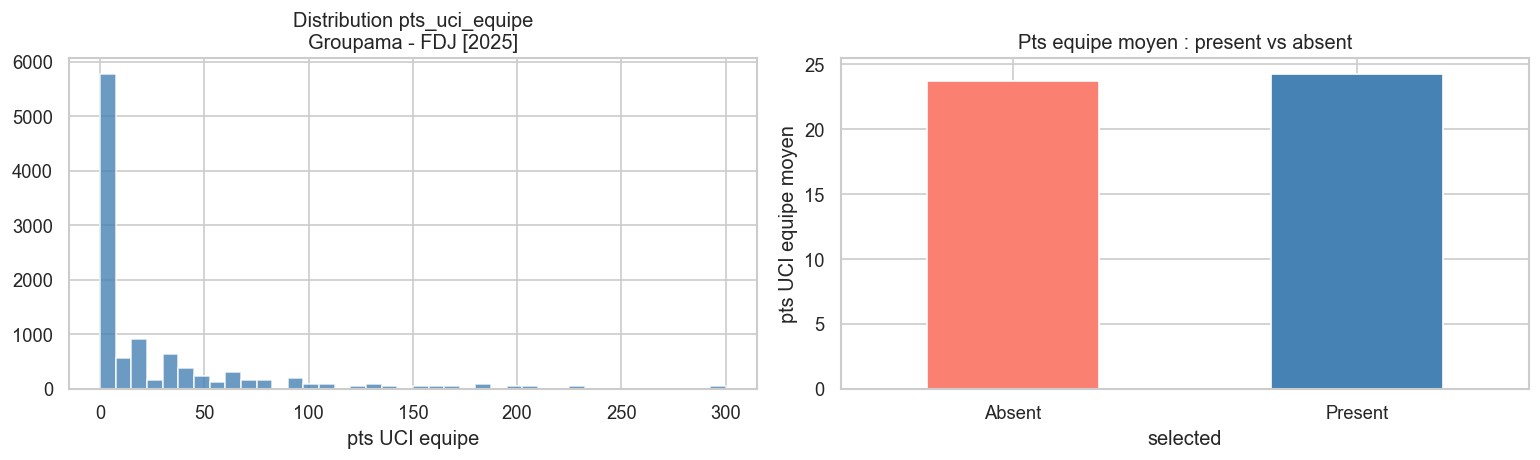

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df_team['pts_uci_equipe'].dropna().clip(0, 300), bins=40,
             color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title(f'Distribution pts_uci_equipe\n{EQUIPE} {ANNEES}')
axes[0].set_xlabel('pts UCI equipe')

df_team.groupby('selected')['pts_uci_equipe'].mean().plot(
    kind='bar', ax=axes[1], color=['salmon', 'steelblue'], edgecolor='white')
axes[1].set_title('Pts equipe moyen : present vs absent')
axes[1].set_xticklabels(['Absent', 'Present'], rotation=0)
axes[1].set_ylabel('pts UCI equipe moyen')
plt.tight_layout()
plt.show()

## 4. Préparation des features

In [20]:
def prepare_features(df):
    features_gpx = [
        'distance_gpx_km', 'denivele_pos', 'denivele_neg',
        'altitude_max', 'altitude_min',
        'n_cols_cat4', 'n_cols_cat3', 'n_cols_cat2', 'n_cols_cat1', 'n_cols_hc',
        'loc_last_col_cat2', 'loc_last_col_cat1', 'loc_last_col_hc',
        'gradient_last_1km', 'gradient_last_3km', 'gradient_last_5km',
        'denivele_last_5km', 'gradient_first_50km', 'denivele_first_50km',
        'cobblestones_km', 'compacted_gravel_km',
    ]
    features_gpx = [f for f in features_gpx if f in df.columns]
    df = df.copy()
    le = LabelEncoder()
    df['classification_enc'] = le.fit_transform(df['classification'].fillna('unknown'))
    features_all = features_gpx + ['classification_enc']
    df_clean = df[features_all + ['selected', 'pts_uci_equipe', 'pts_uci', 'rider', 'course']].dropna(subset=features_gpx)
    X = df_clean[features_all].values
    T = df_clean['selected'].values
    Y = np.log1p(np.clip(df_clean['pts_uci_equipe'].values, 0, None))
    return X, T, Y, df_clean, features_all

# Test sur le premier coureur
df_first = load_rider(RIDERS[0], RACE_PATH, ANNEES, EQUIPE)
X_t, T_t, Y_t, df_clean_t, features_all = prepare_features(df_first)
print(f'Features ({len(features_all)}) : {features_all}')
print(f'Shape dataset : {df_clean_t.shape}')

Features (22) : ['distance_gpx_km', 'denivele_pos', 'denivele_neg', 'altitude_max', 'altitude_min', 'n_cols_cat4', 'n_cols_cat3', 'n_cols_cat2', 'n_cols_cat1', 'n_cols_hc', 'loc_last_col_cat2', 'loc_last_col_cat1', 'loc_last_col_hc', 'gradient_last_1km', 'gradient_last_3km', 'gradient_last_5km', 'denivele_last_5km', 'gradient_first_50km', 'denivele_first_50km', 'cobblestones_km', 'compacted_gravel_km', 'classification_enc']
Shape dataset : (265, 27)


## 5. DML — ATE pour tous les coureurs

In [21]:
def run_dml(X, T, Y, n_folds=5, n_boot=500):
    if T.sum() < 5 or (T==0).sum() < 5:
        return None
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    T_resid = np.zeros(len(T))
    Y_resid = np.zeros(len(Y))
    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X[train_idx], X[val_idx]
        clf = GradientBoostingRegressor(n_estimators=100, random_state=42)
        clf.fit(X_tr, T[train_idx])
        T_resid[val_idx] = T[val_idx] - clf.predict(X_val)
        reg = GradientBoostingRegressor(n_estimators=100, random_state=42)
        reg.fit(X_tr, Y[train_idx])
        Y_resid[val_idx] = Y[val_idx] - reg.predict(X_val)
    ate = np.cov(Y_resid, T_resid)[0, 1] / np.var(T_resid)
    boots = []
    for _ in range(n_boot):
        idx = np.random.choice(len(T_resid), len(T_resid), replace=True)
        boots.append(np.cov(Y_resid[idx], T_resid[idx])[0, 1] / np.var(T_resid[idx]))
    ci_low, ci_high = np.percentile(boots, [2.5, 97.5])
    return {
        'ate_orig': np.expm1(ate),
        'ci_low': np.expm1(ci_low),
        'ci_high': np.expm1(ci_high),
        'significant': ci_low > 0 or ci_high < 0
    }

print(f'Calcul DML pour {len(RIDERS)} coureurs...')
results_dml = []

for f in RIDERS:
    df_r = load_rider(f, RACE_PATH, ANNEES, EQUIPE)
    if df_r is None or len(df_r) == 0:
        continue
    X_r, T_r, Y_r, df_clean_r, _ = prepare_features(df_r)
    nom = f.replace('.csv', '')
    brut = (df_clean_r[df_clean_r['selected']==1]['pts_uci_equipe'].mean() -
            df_clean_r[df_clean_r['selected']==0]['pts_uci_equipe'].mean())
    res = run_dml(X_r, T_r, Y_r)
    if res:
        results_dml.append({
            'rider': nom,
            'n_obs': len(T_r),
            'n_selected': int(T_r.sum()),
            'ate_orig': res['ate_orig'],
            'ci_low': res['ci_low'],
            'ci_high': res['ci_high'],
            'significant': res['significant'],
            'effet_brut': brut
        })
        sig = '✓' if res['significant'] else ' '
        print(f'  [{sig}] {nom:<35} ATE={res["ate_orig"]:+.2f}  IC=[{res["ci_low"]:+.2f}, {res["ci_high"]:+.2f}]')

df_results = pd.DataFrame(results_dml).sort_values('ate_orig', ascending=False)
print(f'\nTotal : {len(df_results)} coureurs | {df_results["significant"].sum()} effets significatifs')

Calcul DML pour 38 coureurs...
  [✓] askey_lewis                         ATE=+1.13  IC=[+0.47, +2.02]
  [ ] barthe_cyril                        ATE=+0.24  IC=[-0.17, +0.79]
  [ ] bock_max                            ATE=+0.14  IC=[-0.39, +1.13]
  [✓] boulet_eliott                       ATE=-0.55  IC=[-0.81, -0.01]
  [✓] bower_lewis                         ATE=-0.49  IC=[-0.64, -0.27]
  [ ] braz_afonso_clément                ATE=+0.24  IC=[-0.16, +0.90]
  [ ] bystrøm_sven_erik                   ATE=-0.31  IC=[-0.61, +0.10]
  [ ] cavagna_rémi                       ATE=-0.04  IC=[-0.33, +0.37]
  [ ] daumas_rémi                        ATE=+0.29  IC=[-0.30, +1.34]
  [✓] davy_clément                       ATE=-0.48  IC=[-0.66, -0.20]
  [ ] decomble_maxime                     ATE=-0.06  IC=[-0.46, +0.67]
  [ ] donnenwirth_tom                     ATE=-0.28  IC=[-0.50, +0.09]
  [ ] fontaine_titouan                    ATE=-0.30  IC=[-0.67, +0.42]
  [ ] gaudu_david                         ATE=

## 6. Visualisation — Forest plot

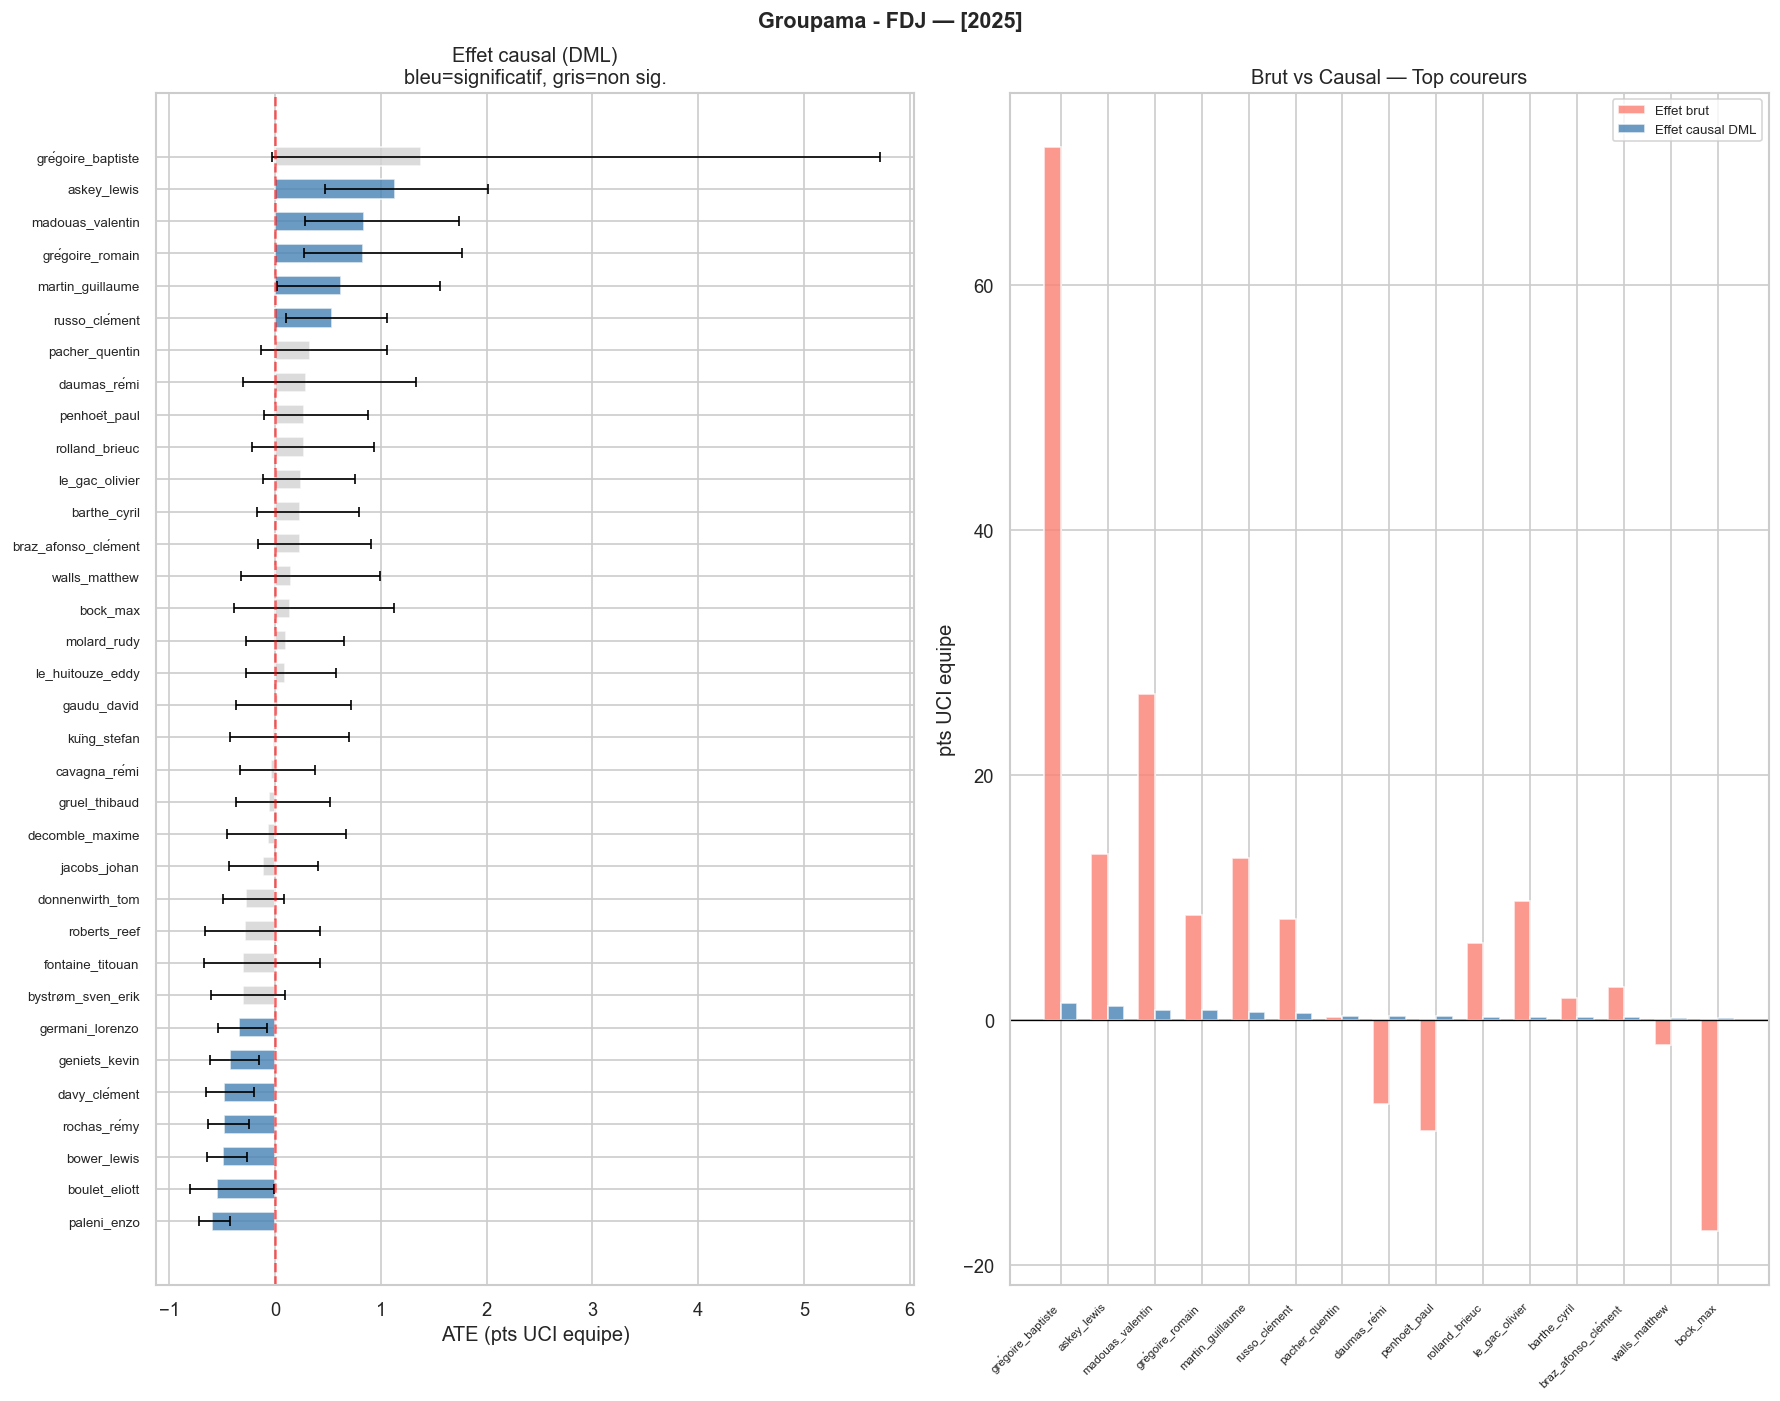

In [22]:
df_plot = df_results.sort_values('ate_orig', ascending=True)
colors = ['steelblue' if s else 'lightgray' for s in df_plot['significant']]

fig, axes = plt.subplots(1, 2, figsize=(15, max(6, len(df_plot)*0.35)))

# Forest plot ATE
y_pos = range(len(df_plot))
axes[0].barh(y_pos, df_plot['ate_orig'], color=colors, edgecolor='white', alpha=0.8, height=0.6)
axes[0].errorbar(
    df_plot['ate_orig'], y_pos,
    xerr=[df_plot['ate_orig'] - df_plot['ci_low'], df_plot['ci_high'] - df_plot['ate_orig']],
    fmt='none', color='black', capsize=3, linewidth=1
)
axes[0].axvline(0, color='red', linestyle='--', alpha=0.6)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(df_plot['rider'], fontsize=8)
axes[0].set_xlabel('ATE (pts UCI equipe)')
axes[0].set_title('Effet causal (DML)\nbleu=significatif, gris=non sig.')

# Effet brut vs causal
df_top = df_results.head(min(15, len(df_results)))
x = np.arange(len(df_top))
w = 0.35
axes[1].bar(x - w/2, df_top['effet_brut'], w, label='Effet brut', color='salmon', alpha=0.8)
axes[1].bar(x + w/2, df_top['ate_orig'],   w, label='Effet causal DML', color='steelblue', alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_top['rider'], rotation=45, ha='right', fontsize=7)
axes[1].set_ylabel('pts UCI equipe')
axes[1].set_title('Brut vs Causal — Top coureurs')
axes[1].legend(fontsize=8)

plt.suptitle(f'{EQUIPE} — {ANNEES}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Causal Forest — Hétérogénéité (coureur au choix)

In [23]:
# Changer ce nom pour analyser un autre coureur
COUREUR_FOCUS = 'grégoire_romain.csv'

df_focus = load_rider(COUREUR_FOCUS, RACE_PATH, ANNEES, EQUIPE)
X_f, T_f, Y_f, df_f_clean, features_all = prepare_features(df_focus)
nom_focus = COUREUR_FOCUS.replace('.csv', '')

print(f'Causal Forest — {nom_focus} ({len(T_f)} obs, {T_f.sum()} selected=1)')
print('Entrainement...')

cf = CausalForestDML(
    model_y=GradientBoostingRegressor(n_estimators=100, random_state=42),
    model_t=GradientBoostingRegressor(n_estimators=100, random_state=42),
    n_estimators=500, random_state=42, cv=5
)
cf.fit(Y_f, T_f, X=X_f)
cate = cf.effect(X_f)
df_f_clean = df_f_clean.copy()
df_f_clean['cate'] = cate

print(f'CATE moyen : {cate.mean():.4f} | std : {cate.std():.4f}')

Causal Forest — grégoire_romain (265 obs, 69 selected=1)
Entrainement...
CATE moyen : 0.6283 | std : 0.3660


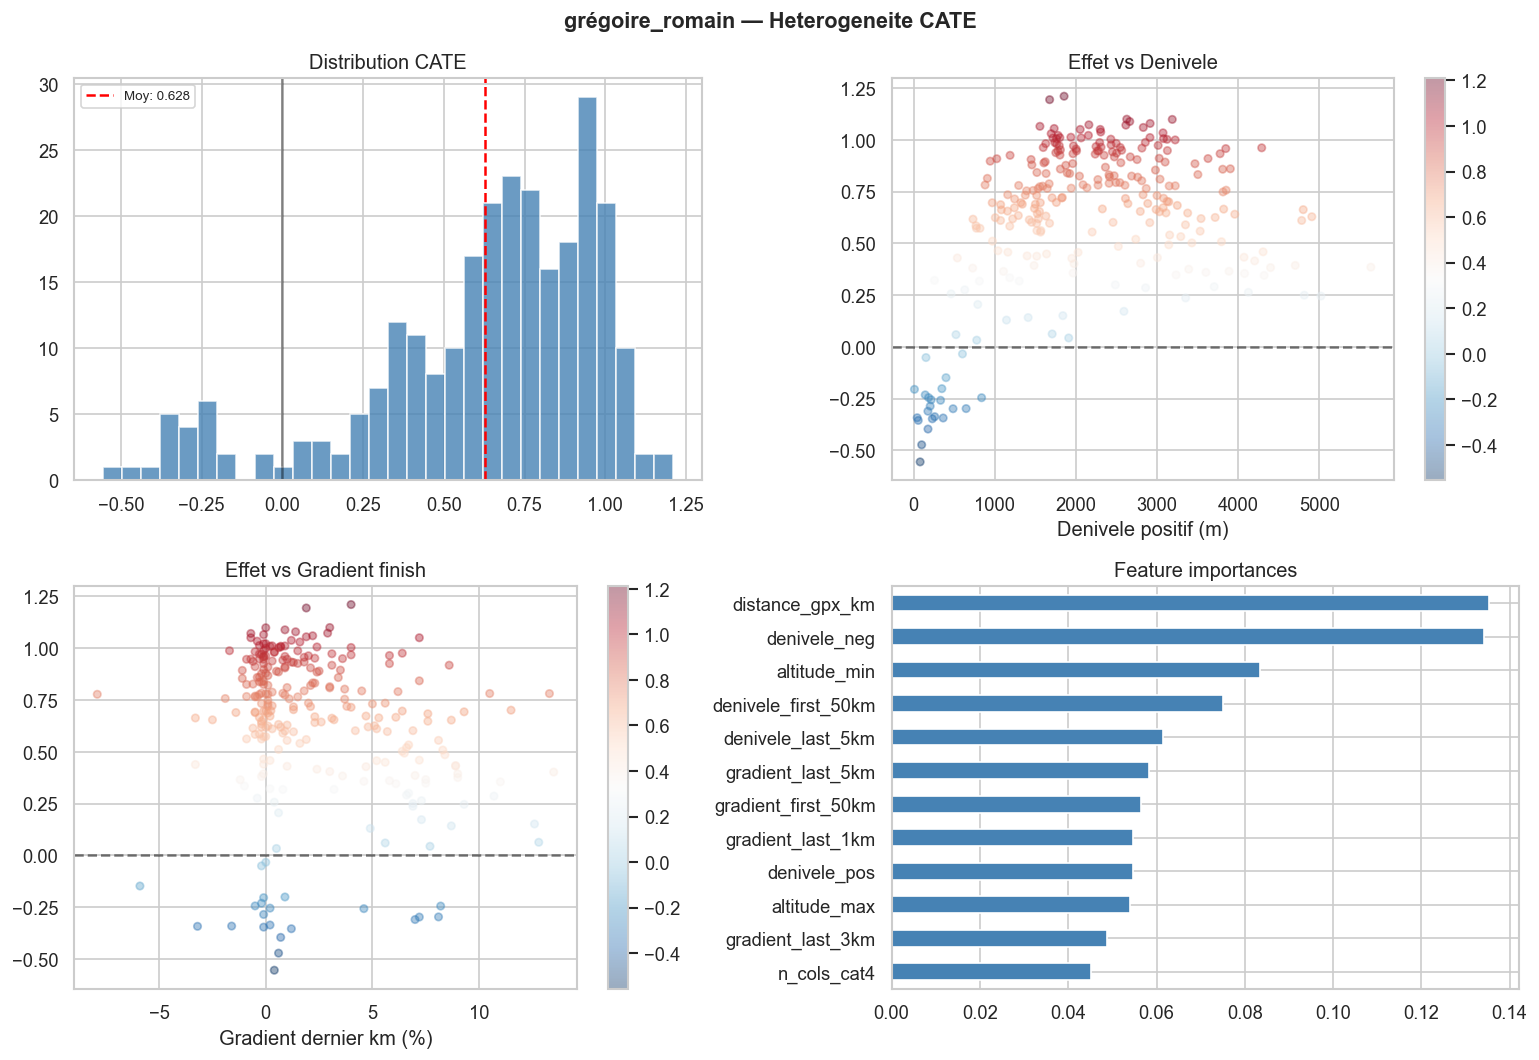

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0,0].hist(cate, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0,0].axvline(cate.mean(), color='red', linestyle='--', label=f'Moy: {cate.mean():.3f}')
axes[0,0].axvline(0, color='black', alpha=0.4)
axes[0,0].set_title('Distribution CATE')
axes[0,0].legend(fontsize=8)

sc1 = axes[0,1].scatter(df_f_clean['denivele_pos'], cate, alpha=0.4, s=20, c=cate, cmap='RdBu_r')
axes[0,1].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[0,1].set_xlabel('Denivele positif (m)')
axes[0,1].set_title('Effet vs Denivele')
plt.colorbar(sc1, ax=axes[0,1])

sc2 = axes[1,0].scatter(df_f_clean['gradient_last_1km'], cate, alpha=0.4, s=20, c=cate, cmap='RdBu_r')
axes[1,0].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[1,0].set_xlabel('Gradient dernier km (%)')
axes[1,0].set_title('Effet vs Gradient finish')
plt.colorbar(sc2, ax=axes[1,0])

feat_imp = pd.Series(cf.feature_importances_, index=features_all).sort_values(ascending=True).tail(12)
feat_imp.plot(kind='barh', ax=axes[1,1], color='steelblue')
axes[1,1].set_title('Feature importances')

plt.suptitle(f'{nom_focus} — Heterogeneite CATE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

CATE par profil de course — grégoire_romain :
                     mean     std  count
denivele_q                              
Q1 Plat            0.2697  0.4366     67
Q2 Vallonne        0.7652  0.2460     66
Q3 Montagneux      0.8290  0.2058     66
Q4 Haute montagne  0.6548  0.2375     66


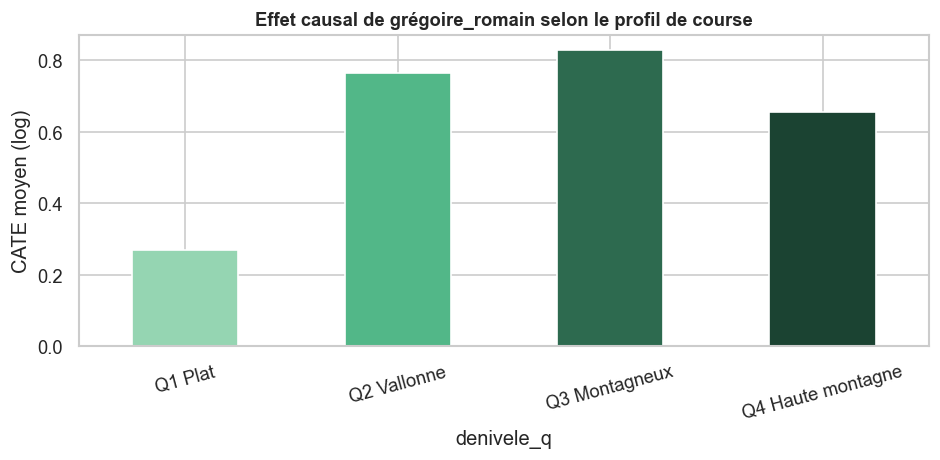

In [25]:
# CATE par quartile de denivele
df_f_clean['denivele_q'] = pd.qcut(
    df_f_clean['denivele_pos'], q=4,
    labels=['Q1 Plat', 'Q2 Vallonne', 'Q3 Montagneux', 'Q4 Haute montagne']
)
cate_q = df_f_clean.groupby('denivele_q')['cate'].agg(['mean', 'std', 'count']).round(4)
print(f'CATE par profil de course — {nom_focus} :')
print(cate_q)

fig, ax = plt.subplots(figsize=(8, 4))
cate_q['mean'].plot(kind='bar', ax=ax, color=['#95d5b2','#52b788','#2d6a4f','#1b4332'], edgecolor='white')
ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.set_title(f'Effet causal de {nom_focus} selon le profil de course', fontsize=11, fontweight='bold')
ax.set_ylabel('CATE moyen (log)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 8. Résumé final

In [26]:
print('=' * 60)
print(f'RÉSUMÉ — {EQUIPE} {ANNEES}')
print('=' * 60)
print(f'Coureurs analyses        : {len(df_results)}')
print(f'Effets significatifs     : {df_results["significant"].sum()}')
print(f'\nTop 5 par ATE causal :')
print(df_results.head(5)[['rider', 'n_selected', 'ate_orig', 'ci_low', 'ci_high', 'significant']].to_string(index=False))
print(f'\nBottom 5 par ATE causal :')
print(df_results.tail(5)[['rider', 'n_selected', 'ate_orig', 'ci_low', 'ci_high', 'significant']].to_string(index=False))
print(f'\nFocus {nom_focus} :')
focus_row = df_results[df_results['rider'] == nom_focus]
if len(focus_row) > 0:
    r = focus_row.iloc[0]
    print(f'  ATE    : +{r["ate_orig"]:.2f} pts  IC=[{r["ci_low"]:.2f}, {r["ci_high"]:.2f}]')
    print(f'  Brut   : +{r["effet_brut"]:.2f} pts')
    print(f'  Sig.   : {r["significant"]}')
print('=' * 60)

RÉSUMÉ — Groupama - FDJ [2025]
Coureurs analyses        : 34
Effets significatifs     : 12

Top 5 par ATE causal :
             rider  n_selected  ate_orig    ci_low  ci_high  significant
grégoire_baptiste           5  1.377245 -0.031334 5.719138        False
       askey_lewis          69  1.129925  0.466851 2.016564         True
  madouas_valentin          67  0.839286  0.280197 1.738773         True
  grégoire_romain          69  0.833210  0.275668 1.769195         True
  martin_guillaume          59  0.618211  0.013798 1.556873         True

Bottom 5 par ATE causal :
        rider  n_selected  ate_orig    ci_low   ci_high  significant
davy_clément          72 -0.480391 -0.657091 -0.196830         True
 rochas_rémy          79 -0.483395 -0.632197 -0.247031         True
  bower_lewis          34 -0.490101 -0.643590 -0.268541         True
boulet_eliott           8 -0.551606 -0.805170 -0.010070         True
  paleni_enzo          74 -0.594265 -0.724649 -0.425337         True

Focus